<a href="https://colab.research.google.com/github/njokinjuguna/ml-learning-labs/blob/main/AI-Powered%20Bank%20Customer%20Retention%20Intelligence%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# # AI-Powered Customer Churn Risk Intelligence System

## Project Overview

Customer churn is one of the biggest challenges faced by financial institutions. Losing existing customers not only reduces long-term revenue but also increases customer acquisition costs. In the banking industry, retaining high-value customers is often more cost-effective than acquiring new ones.

This project was developed as an intelligent churn risk management system designed to help banks proactively identify customers who are likely to leave and apply targeted retention strategies before churn occurs.

Unlike traditional machine learning projects that focus only on model accuracy, this system was designed with a strong emphasis on real business impact and operational decision-making.

---

## Business Problem

One of the major challenges in churn prediction is class imbalance. In real banking environments, most customers do not churn, while only a smaller percentage leave the bank. This creates a situation where a model can achieve high accuracy while still failing to detect actual churners effectively.

For example, a model may achieve over 85% accuracy simply by predicting that most customers will stay, yet still miss a large number of high-risk customers. In a real business environment, missing potential churners (False Negatives) can lead to significant financial losses.

This project therefore focused on minimizing False Negatives rather than optimizing accuracy alone.

---

## Engineering Approach

The system was developed using multiple machine learning approaches including:

* Logistic Regression (Baseline Model)
* Artificial Neural Networks (ANN)
* XGBoost (Final Production-Oriented Model)

After extensive evaluation, XGBoost was selected as the primary production model due to its strong performance on structured tabular banking data and its flexibility in handling class imbalance and probability-based risk scoring.

The project evolved beyond simple binary classification into a full risk intelligence framework.

---

## Key Production-Oriented Enhancements

### 1. Cost-Sensitive Learning

Class imbalance was addressed using weighted learning techniques to penalize missed churners more heavily during training.

### 2. Threshold Optimization

Instead of relying on the default 0.5 prediction threshold, custom threshold tuning was implemented to improve churn detection recall and reduce False Negatives.

### 3. Probability-Based Risk Scoring

Rather than generating only “Churn” or “No Churn” predictions, the system produces churn probability scores for each customer.

### 4. Risk Tier Segmentation

Customers are categorized into multiple risk levels such as:

* Critical Risk
* High Risk
* Medium Risk
* Low Risk
* Very Low Risk

### 5. Business-Aware Retention Strategy

Different retention actions are recommended depending on customer risk level. This helps balance customer retention performance with operational cost control.

Examples include:

* Immediate retention calls for critical-risk customers
* Personalized offers for high-risk customers
* Automated email/SMS engagement for medium-risk customers
* Monitoring strategies for lower-risk customers

---

## Business Value

This project demonstrates that successful machine learning systems are not only about building accurate models, but also about solving real operational and business problems.

The final system was designed to:

* Reduce customer churn risk
* Minimize missed churners
* Control operational retention costs
* Prioritize high-risk customers intelligently
* Support data-driven business decisions

---

## Final Outcome

The project successfully transformed a traditional churn classification task into a production-oriented customer retention intelligence system capable of supporting strategic business intervention and proactive customer engagement.


# Libraries

In [136]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf
import xgboost as xgb
from xgboost import XGBClassifier
from tensorflow import keras
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,classification_report

# Data importation

In [137]:
#data loading
df=pd.read_csv('Churn_Modelling.csv')
df.shape

(10000, 14)

# EDA

In [138]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Data exploration and cleaning

In [139]:
#Separate features and target
y = df['Exited']
y.value_counts()

,count
Exited,
0,7963
1,2037


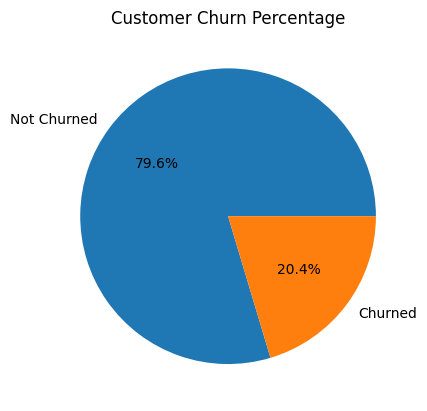

In [140]:
#from the above we realise the data is imbalanced...lets visualize well in a graph
y.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Not Churned', 'Churned']
)
plt.title('Customer Churn Percentage')
plt.ylabel('')
plt.show()

In [141]:
#Drop unnecessary columns + target from features
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
df.iloc[:10]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [142]:
#Gender encode
# 0=Female,1= Male
le=LabelEncoder()
X['Gender']=le.fit_transform(X['Gender'])
X.iloc[:10]


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58
2,502,France,0,42,8,159660.80,3,1,0,113931.57
3,699,France,0,39,1,0.00,2,0,0,93826.63
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10
5,645,Spain,1,44,8,113755.78,2,1,0,149756.71
6,822,France,1,50,7,0.00,2,1,1,10062.80
7,376,Germany,0,29,4,115046.74,4,1,0,119346.88
8,501,France,1,44,4,142051.07,2,0,1,74940.50
9,684,France,1,27,2,134603.88,1,1,1,71725.73


In [143]:
#Geography--one-hot encoding
df=pd.get_dummies(X,columns=['Geography'])
df.iloc[:10]

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,False,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,True,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,False,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,True,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,True,False,False


In [144]:
#convert geography to int
for col in df.columns:
    if "Geography_" in col:
        df[col] = df[col].astype(int)

In [145]:
#drop missing values
df.isna().sum()

,0
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Geography_France,0


In [146]:
df.dtypes

,0
CreditScore,int64
Gender,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Geography_France,int64


In [147]:
#data spliting
X_train,X_test,y_train,y_test=train_test_split(df,y,test_size=0.2,random_state=5)

In [148]:
# #scaling the data
cols_to_scale = [
    'CreditScore',
    'Balance',
    'EstimatedSalary',
    'Tenure',
    'Age',
    'NumOfProducts'
]

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


In [149]:
X_train.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7751,0.800,0,0.283784,0.6,0.000000,0.333333,0,0,0.096273,0,0,1
4154,0.752,1,0.216216,0.3,0.000000,0.333333,1,0,0.981478,1,0,0
3881,0.476,0,0.621622,0.3,0.000000,0.000000,1,1,0.948551,1,0,0
9238,0.846,0,0.432432,0.4,0.000000,0.333333,1,0,0.646869,1,0,0
5210,0.402,1,0.229730,0.7,0.517012,0.333333,0,0,0.434670,1,0,0


In [150]:
X_train.shape


(8000, 12)

In [151]:
X_test.shape

(2000, 12)

In [152]:
y_train.shape

(8000,)

In [153]:
X_train.dtypes

,0
CreditScore,float64
Gender,int64
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Geography_France,int64


#BASELINE Model

In [183]:
#lets use logistic regression to help us understand whether your dataset actually contains predictive information.
#why we use it is because our dataset is tabular and a binary classification
model=LogisticRegression()
model.fit(X_train,y_train)

print(f"Logistic Regression Accuracy: {model.score(X_test, y_test)}")

Logistic Regression Accuracy: 0.8065


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1595
           1       0.57      0.18      0.27       405

    accuracy                           0.81      2000
   macro avg       0.70      0.57      0.58      2000
weighted avg       0.77      0.81      0.76      2000



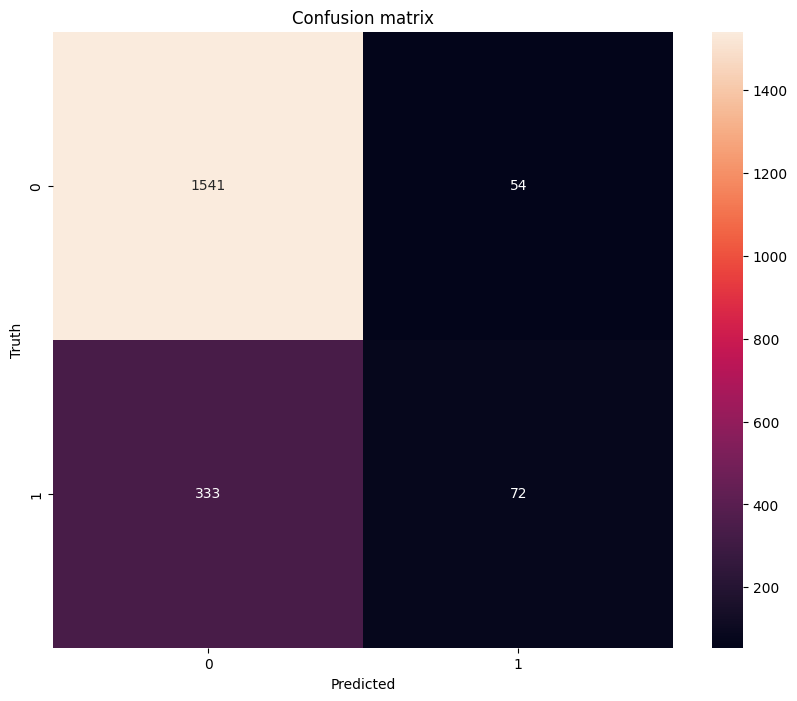

In [184]:
#Model prediction
y_pred_reg = model.predict(X_test)


#lets convert the y_pred_reg into 0 and 1 so that we can be able to compare well with y_test
y_predict_reg=[]
for p in y_pred_reg:
    if p>0.5:
      y_predict_reg.append(1)
    else:
      y_predict_reg.append(0)


cr_log_reg = classification_report(y_test, y_predict_reg)
print(cr_log_reg)

cm_log_reg =tf.math.confusion_matrix(y_test, y_predict_reg)
plt.figure(figsize=(10,8))
sns.heatmap(cm_log_reg, annot=True,fmt='d')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()


# ANN model setup

In [156]:
model=keras.Sequential([
    keras.layers.Dense(30,input_shape=(12,),activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model.fit(X_train,y_train,epochs=100,class_weight={0:1, 1:2})

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7814 - loss: 0.7157
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7890 - loss: 0.6694
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7931 - loss: 0.6522
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8005 - loss: 0.6359
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8037 - loss: 0.6196
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8177 - loss: 0.5921
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8273 - loss: 0.5641
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8349 - loss: 0.5452
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8317 - loss: 0.5367
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8347 - loss: 0.5301
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8365 - loss: 0.5242
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [157]:
#MODEL Evaluation
print(f"ANN Accuracy: {model.evaluate(X_test, y_test)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8220 - loss: 0.4096
ANN Accuracy: [0.4096250534057617, 0.8220000267028809]


In [158]:
#MODEL Prediction
y_prediction=model.predict(X_test)
y_prediction[:10]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.05986138],
       [0.19264536],
       [0.06052465],
       [0.13236319],
       [0.15126877],
       [0.3314162 ],
       [0.05521275],
       [0.44752344],
       [0.03625612],
       [0.99373484]], dtype=float32)

In [159]:
#lets convert the y_predicts into 0 and 1 so that we can be able to compare well with y_test
y_predict=[]
for p in y_prediction:
    if p>0.5:
      y_predict.append(1)
    else:
      y_predict.append(0)

In [160]:
y_predict[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [161]:
y_test[:10]

,Exited
7054,0
442,0
3954,0
2288,0
3196,0
6178,0
8351,0
5658,1
2065,0
413,1


model a classification report

In [162]:
class_report = classification_report(y_test, y_predict)
print(class_report)


              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1595
           1       0.55      0.66      0.60       405

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000



visualization of the confusion matrix

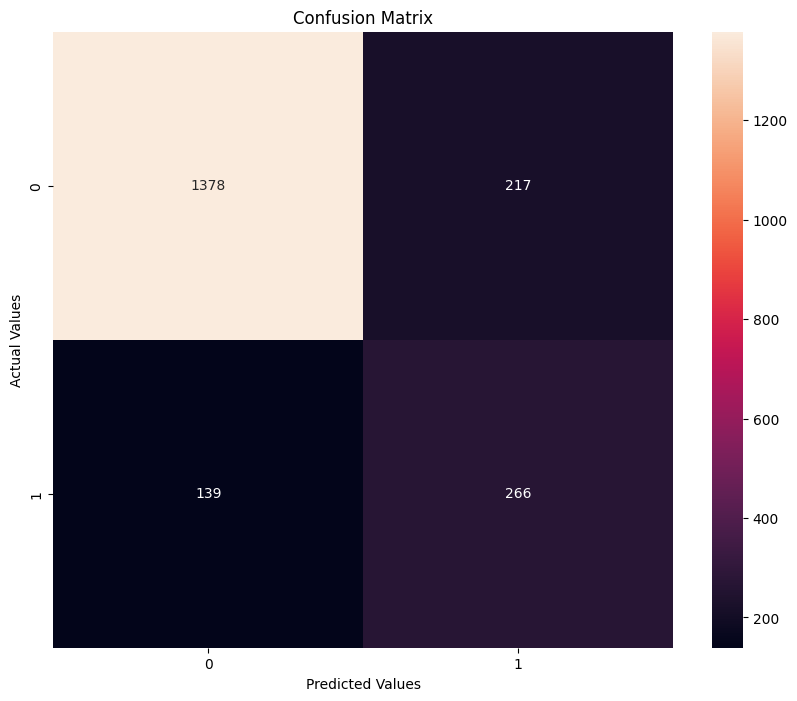

In [163]:
cm = tf.math.confusion_matrix(y_test, y_predict)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

In [164]:
precision_for_0=round(1363/(1363+140),2)
precision_for_0

0.91

In [165]:
precision_for_1=round(265/(232+265),2)
precision_for_1

0.53

In [166]:
recall_for_0=round(1363/(1363+140),2)
recall_for_0

0.91

In [167]:
recal1_for_1=round(265/(265+140),2)
recal1_for_1

0.65

In [168]:
accuracy=round((1363+265)/(1363+140+265+140),2)
accuracy

0.85

In [169]:
F1_SCORE_0=(2*precision_for_0*recall_for_0)/(precision_for_0+recall_for_0)
F1_SCORE_0


0.91

In [170]:
F1_SCORE_1=(2*precision_for_1*recal1_for_1)/(precision_for_1+recal1_for_1)
F1_SCORE_1

0.5838983050847457

lets compare the prediction reports for the 3 MODELS

# XGBoost

##1. TRAIN COST-SENSITIVE XGBOOST


In [171]:
#lets try with the Xgboost and see
xgb.XGBClassifier()
model = xgb.XGBClassifier(

    # imbalance handling
    scale_pos_weight = 3.94,

    # objective
    objective='binary:logistic',

    # evaluation
    eval_metric='logloss',

    # reproducibility
    random_state=42
)

# Train model
model.fit(X_train,y_train)




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## 2. GENERATE CHURN PROBABILITIES


In [172]:
# Get churn probabilities
y_prob_xgb = model.predict_proba(X_test)[:,1]


# #Model prediction
# y_pred_xgb = model.predict(X_test)  #the reason we commented/removed this part is because anytime you call model.predict is gives a default threshold of 0.5 and we need to scrap that

##3. THRESHOLD OPTIMIZATION



In [173]:
# Threshold candidates
# Selected threshold from analysis
threshold = 0.30


In [174]:
# Final churn predictions
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

## 4. MODEL EVALUATION



CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1595
           1       0.43      0.75      0.55       405

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75      0.77      2000


CONFUSION MATRIX VALUES

True Negatives  : 1196
False Positives : 399
False Negatives : 102
True Positives  : 303


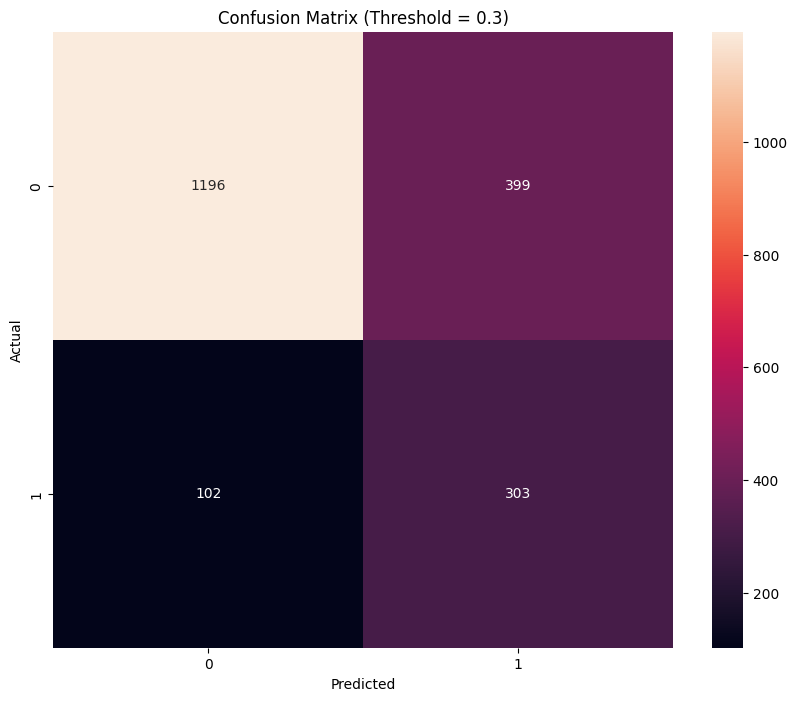

In [175]:
print("\nCLASSIFICATION REPORT\n")


cr_xgb_final = classification_report(
    y_test,
    y_pred_xgb
)

print(cr_xgb_final)


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

TN, FP, FN, TP = cm.ravel()

print("\nCONFUSION MATRIX VALUES\n")

print(f"True Negatives  : {TN}")
print(f"False Positives : {FP}")
print(f"False Negatives : {FN}")
print(f"True Positives  : {TP}")

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(f'Confusion Matrix (Threshold = {threshold})')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

##5. CREATE RISK SCORES


In [176]:
# Create risk dataframe
risk_df = pd.DataFrame()

risk_df['Actual_Churn'] = y_test.values
risk_df['Churn_Probability'] = y_prob_xgb

## 6. CREATE RISK TIERS


In [177]:
def assign_risk(prob):

    if prob >= 0.80:
        return "Critical Risk"

    elif prob >= 0.60:
        return "High Risk"

    elif prob >= 0.40:
        return "Medium Risk"

    elif prob >= 0.30:
        return "Low Risk"

    else:
        return "Very Low Risk"

risk_df['Risk_Level'] = risk_df['Churn_Probability'].apply(assign_risk)

## 7. BUSINESS ACTION STRATEGY

In [178]:
def retention_action(risk):

    if risk == "Critical Risk":
        return "Immediate retention call"

    elif risk == "High Risk":
        return "Personalized retention offer"

    elif risk == "Medium Risk":
        return "Automated email/SMS campaign"

    elif risk == "Low Risk":
        return "Monitor customer behavior"

    else:
        return "No action required"

risk_df['Business_Action'] = risk_df[
    'Risk_Level'
].apply(retention_action)

## 8. SORT BY HIGHEST RISK

In [179]:
risk_df = risk_df.sort_values(
    by='Churn_Probability',
    ascending=False
)


## 9. DISPLAY RESULTS

In [180]:
# Reset index and create Customer_ID column
risk_df = risk_df.reset_index()

risk_df.rename(
    columns={'index': 'Customer_ID'},
    inplace=True
)


print("\nTOP HIGH-RISK CUSTOMERS\n")

print(risk_df.head(20))


TOP HIGH-RISK CUSTOMERS

    Customer_ID  Actual_Churn  Churn_Probability     Risk_Level  \
0           817             1           0.999969  Critical Risk   
1          1263             1           0.999964  Critical Risk   
2           281             1           0.999889  Critical Risk   
3          1411             1           0.999851  Critical Risk   
4          1863             1           0.999840  Critical Risk   
5           471             1           0.999818  Critical Risk   
6           719             1           0.999804  Critical Risk   
7           782             1           0.999758  Critical Risk   
8          1196             1           0.999632  Critical Risk   
9          1616             1           0.999624  Critical Risk   
10          182             1           0.999593  Critical Risk   
11          925             1           0.999585  Critical Risk   
12         1215             1           0.999579  Critical Risk   
13         1925             1       

##  10. RISK DISTRIBUTION

In [181]:
print("\nRISK DISTRIBUTION\n")

print(
    risk_df['Risk_Level']
    .value_counts()
)


RISK DISTRIBUTION

Risk_Level
Very Low Risk    1298
Critical Risk     219
Medium Risk       208
High Risk         159
Low Risk          116
Name: count, dtype: int64


### interpretation

Interpretation

The model is saying:

“This customer has an extremely high probability of churning.”

Example:

0.999969≈99.99%

0.999969≈99.99%

So:

Risk_Level = Critical Risk
Business_Action = Immediate retention call


BUSINESS INTERPRETATION
1. Critical Risk (219 customers)

These are:

highest churn probability
most dangerous customers
should get expensive interventions

Example:

human retention calls
special offers
account manager outreach
2. High Risk (159 customers)

These are:

likely churners
but slightly less certain

Cheaper interventions:

personalized email
targeted promotion
discount campaign
3. Medium Risk (208 customers)

These customers:

show some churn behavior
should be monitored

Low-cost actions:

SMS reminders
app engagement
loyalty offers
4. Very Low Risk (1298 customers)

These customers are:

stable
unlikely to churn

Meaning:

DO NOT waste money calling them

THIS is where cost savings happen.

Business Summary
The model prioritizes minimizing missed churners.
Customers are ranked by churn risk probability.
Different intervention strategies are applied based on risk level.
High-cost retention actions are reserved only for highest-risk customers.
Lower-risk customers receive automated low-cost engagement.
This balances customer retention with operational cost control.

# Summary Performance report for The 3 MODELS

In [188]:
#lets compare the 3 models classification reports
print("Logistic Regression\n\n")
print(cr_log_reg)
print("ANN\n\n")
print(class_report)
print("XGBoost\n\n")
print(cr_xgb_final)

Logistic Regression


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1595
           1       0.57      0.18      0.27       405

    accuracy                           0.81      2000
   macro avg       0.70      0.57      0.58      2000
weighted avg       0.77      0.81      0.76      2000

ANN


              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1595
           1       0.55      0.66      0.60       405

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000

XGBoost


              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1595
           1       0.43      0.75      0.55       405

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75   